# Exercise: Exploration Strategies
## AIAT 123 - Reinforcement Learning

## Learning Objectives
- Implement epsilon-greedy strategy
- Implement UCB algorithm
- Compare exploration strategies
- Apply to A/B testing

## Real-World Context
You're optimizing ad placement for an e-commerce platform.

## Exercise Brief

This exercise checks whether students can compare exploration strategies in a structured way.

They should not only run the code, but also explain why different strategies behave differently.

Why this matters: Unit 4 is about judgment and interpretation, not only implementation.

This exercise is meant to make students defend what they observe.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Exercise Goal

In this exercise, you will build a small bandit setup and compare exploration
strategies using reward and regret, not just raw code.


## Student Support Pack

Use this section before coding so you know what the exercise is testing conceptually.

### Key Terms
- Exploration: trying uncertain actions.
- Exploitation: using the current best action.
- Epsilon: explore probability.
- Regret: loss from not always choosing the best action.

### Quick Check
- Why is pure exploitation risky early?
- What changes when epsilon is high or low?
- How do the plots reveal the trade-off?

### Common Mistakes
- Assuming exploration means permanent randomness.
- Using one lucky run as proof.
- Confusing exploration rate with learning rate.


### Step Guide

**What this cell does:** Install or import dependencies so later cells can run.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Pip progress lines and usually a confirmation that imports work.

**If you feel lost:** Fix any red install error before continuing—later cells assume this cell succeeded.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

# Line magic: Jupyter/IPython directive for this line only.
%pip install numpy matplotlib -q
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt
# Show text or numbers in the cell output area under the code.
print('✅ Setup complete!')



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!


## Task 1: Multi-Armed Bandit (20 points)

Simulate a multi-armed bandit with different ad CTRs.

### Step Guide

**What this cell does:** Follow the printed section: "Bandit ready with"

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

# Class `MultiArmedBandit` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class MultiArmedBandit:
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, n_arms, true_rewards.
    def __init__(self, n_arms, true_rewards):
        # Save a value in a name so the next lines can read it.
        self.n_arms = n_arms
        # Another assignment—same idea: store a value for the lines below.
        self.true_rewards = np.asarray(true_rewards, dtype=float)

    # Function `pull` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, arm.
    def pull(self, arm):
        # Send a value back to whoever called this function.
        return float(np.random.binomial(1, self.true_rewards[arm]))


# Save a value in a name so the next lines can read it.
bandit = MultiArmedBandit(4, [0.10, 0.18, 0.30, 0.22])
# Show text or numbers in the cell output area under the code.
print("Bandit ready with", bandit.n_arms, "arms")
# Show text or numbers in the cell output area under the code.
print("Task 1 prompt: explain why the true rewards are hidden from the agent.")


Bandit ready with 4 arms
Task 1 prompt: explain why the true rewards are hidden from the agent.


## Task 2: Epsilon-Greedy (25 points)

Implement epsilon-greedy exploration strategy.

### Step Guide

**What this cell does:** Define a helper you can read in one place before it is used later.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [3]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

# Function `epsilon_greedy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: bandit, epsilon, n_steps.
def epsilon_greedy(bandit, epsilon=0.1, n_steps=1000):
    # Save a value in a name so the next lines can read it.
    q = np.zeros(bandit.n_arms)
    # Another assignment—same idea: store a value for the lines below.
    n = np.zeros(bandit.n_arms)
    # Unpack the one-step model output from transition(state, action).
    rewards = []
    # Save a value in a name so the next lines can read it.
    chosen_actions = []

    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(n_steps):
        # If the condition is True, run the indented block under this line.
        if np.random.rand() < epsilon:
            # Save a value in a name so the next lines can read it.
            action = np.random.randint(bandit.n_arms)
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Save a value in a name so the next lines can read it.
            action = int(np.argmax(q))
        # Unpack the one-step model output from transition(state, action).
        reward = bandit.pull(action)
        # Save a value in a name so the next lines can read it.
        n[action] += 1
        # Another assignment—same idea: store a value for the lines below.
        q[action] += (reward - q[action]) / n[action]
        # Add one new item to the end of a list (the list grows in place).
        rewards.append(reward)
        # Add one new item to the end of a list (the list grows in place).
        chosen_actions.append(action)

    # Send a value back to whoever called this function.
    return q, np.array(rewards), np.array(chosen_actions)


# Save a value in a name so the next lines can read it.
q_eg, rewards_eg, actions_eg = epsilon_greedy(bandit, epsilon=0.1, n_steps=500)
# Show text or numbers in the cell output area under the code.
print("epsilon-greedy estimated values:", np.round(q_eg, 3))


epsilon-greedy estimated values: [0.069 0.143 0.176 0.258]


## Task 3: UCB Algorithm (30 points)

Implement Upper Confidence Bound algorithm.

### Step Guide

**What this cell does:** Define a helper you can read in one place before it is used later.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [4]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

# Function `ucb` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: bandit, c, n_steps.
def ucb(bandit, c=2.0, n_steps=1000):
    # Save a value in a name so the next lines can read it.
    q = np.zeros(bandit.n_arms)
    # Another assignment—same idea: store a value for the lines below.
    n = np.zeros(bandit.n_arms)
    # Unpack the one-step model output from transition(state, action).
    rewards = []
    # Save a value in a name so the next lines can read it.
    chosen_actions = []

    # Start a loop: repeat the indented block once per item in the sequence.
    for t in range(1, n_steps + 1):
        # Save a value in a name so the next lines can read it.
        exploration_bonus = np.full(bandit.n_arms, np.inf)
        # Another assignment—same idea: store a value for the lines below.
        tried = n > 0
        # Another assignment—same idea: store a value for the lines below.
        exploration_bonus[tried] = c * np.sqrt(np.log(t + 1) / n[tried])
        # Another assignment—same idea: store a value for the lines below.
        action = int(np.argmax(q + exploration_bonus))
        # Unpack the one-step model output from transition(state, action).
        reward = bandit.pull(action)
        # Save a value in a name so the next lines can read it.
        n[action] += 1
        # Another assignment—same idea: store a value for the lines below.
        q[action] += (reward - q[action]) / n[action]
        # Add one new item to the end of a list (the list grows in place).
        rewards.append(reward)
        # Add one new item to the end of a list (the list grows in place).
        chosen_actions.append(action)

    # Send a value back to whoever called this function.
    return q, np.array(rewards), np.array(chosen_actions)


# Save a value in a name so the next lines can read it.
bandit_ucb = MultiArmedBandit(4, [0.10, 0.18, 0.30, 0.22])
# Another assignment—same idea: store a value for the lines below.
q_ucb, rewards_ucb, actions_ucb = ucb(bandit_ucb, c=2.0, n_steps=500)
# Show text or numbers in the cell output area under the code.
print("UCB estimated values:", np.round(q_ucb, 3))


UCB estimated values: [0.068 0.184 0.299 0.19 ]


## Task 4: Comparison (25 points)

Compare strategies and analyze results.

### Step Guide

**What this cell does:** Define a helper you can read in one place before it is used later.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


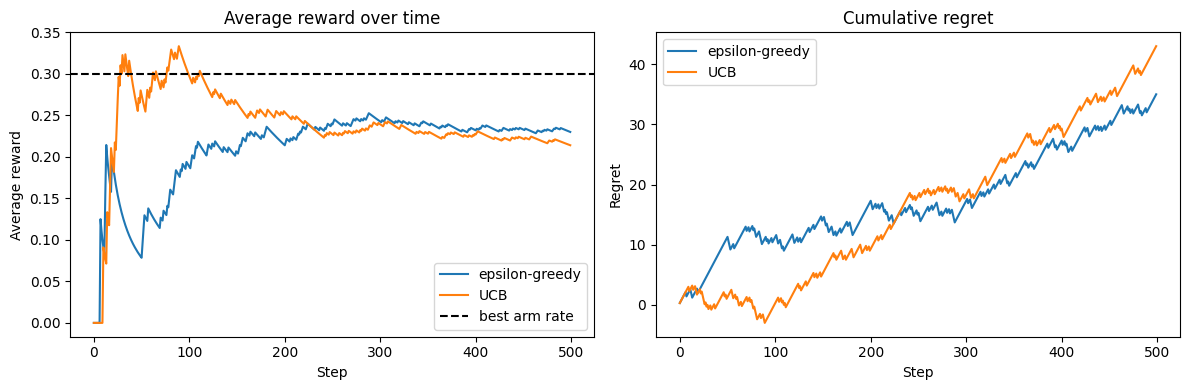

Reflection prompts:
1. Which strategy found the best arm faster?
2. Which strategy accumulated less regret?
3. Why might UCB outperform epsilon-greedy in this setup?


In [5]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

# Function `cumulative_average` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: rewards.
def cumulative_average(rewards):
    # Send a value back to whoever called this function.
    return np.cumsum(rewards) / np.arange(1, len(rewards) + 1)


# Function `cumulative_regret` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: true_best_reward, rewards.
def cumulative_regret(true_best_reward, rewards):
    # Send a value back to whoever called this function.
    return np.cumsum(true_best_reward - rewards)


# Save a value in a name so the next lines can read it.
best_possible = np.max(bandit.true_rewards)

# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(12, 4))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1, 2, 1)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(cumulative_average(rewards_eg), label="epsilon-greedy")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(cumulative_average(rewards_ucb), label="UCB")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.axhline(best_possible, linestyle="--", color="black", label="best arm rate")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Average reward over time")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel("Step")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.ylabel("Average reward")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.legend()

# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1, 2, 2)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(cumulative_regret(best_possible, rewards_eg), label="epsilon-greedy")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(cumulative_regret(best_possible, rewards_ucb), label="UCB")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Cumulative regret")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel("Step")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.ylabel("Regret")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()

# Show text or numbers in the cell output area under the code.
print("Reflection prompts:")
# Show text or numbers in the cell output area under the code.
print("1. Which strategy found the best arm faster?")
# Show text or numbers in the cell output area under the code.
print("2. Which strategy accumulated less regret?")
# Show text or numbers in the cell output area under the code.
print("3. Why might UCB outperform epsilon-greedy in this setup?")


## Submission

**Total: 100 points**

Real-world: A/B testing, ad optimization, recommendation systems

## 🌍 Real-World Worked Example — A/B Testing with Multi-Armed Bandits

**Industry context:**
- Netflix shows different thumbnails to different users and picks the best one using Thompson Sampling — same as this example
- Google Ads uses epsilon-greedy to balance showing ads that already work vs. testing new ones
- Booking.com runs 1000+ bandit experiments simultaneously

We compare **ε-greedy**, **UCB**, and **Thompson Sampling** on a real A/B test simulation.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


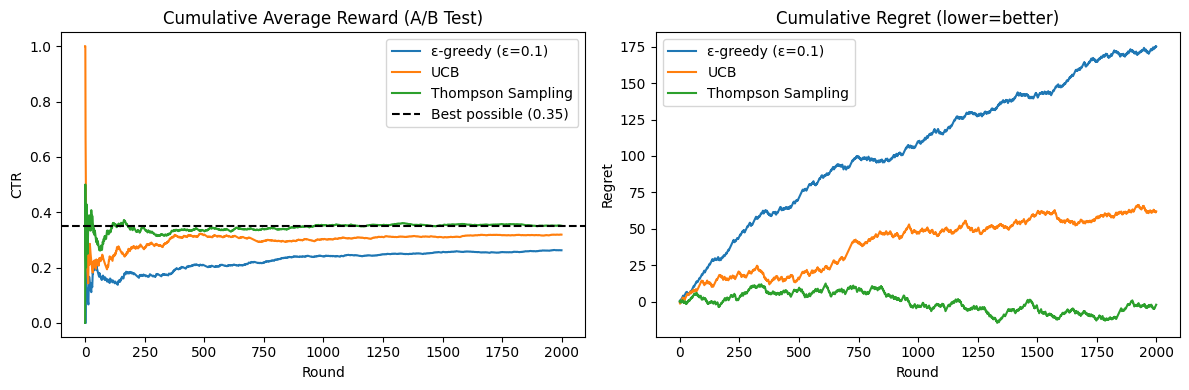


Total rewards — ε-greedy: 525, UCB: 638, Thompson: 702


In [6]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np, matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)
# ── Scenario: 5 website variants (like Netflix thumbnails)
# True click-through rates (unknown to agent)
# Save a value in a name so the next lines can read it.
TRUE_RATES = [0.15, 0.22, 0.35, 0.18, 0.28]   # Variant 3 is best (35%)
# Another assignment—same idea: store a value for the lines below.
N_ARMS   = len(TRUE_RATES)
# Another assignment—same idea: store a value for the lines below.
N_ROUNDS = 2000
# Another assignment—same idea: store a value for the lines below.
BEST_RATE = max(TRUE_RATES)

# Function `pull` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: arm.
def pull(arm): return 1 if np.random.rand() < TRUE_RATES[arm] else 0

# Function `epsilon_greedy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: eps.
def epsilon_greedy(eps):
    # Save a value in a name so the next lines can read it.
    counts = np.zeros(N_ARMS); totals = np.zeros(N_ARMS); rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        arm = np.random.randint(N_ARMS) if np.random.rand() < eps else np.argmax(totals / (counts + 1e-9))
        # Add one new item to the end of a list (the list grows in place).
        r = pull(arm); counts[arm] += 1; totals[arm] += r; rewards.append(r)
    # Send a value back to whoever called this function.
    return rewards

# Function `ucb` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: no named parameters in the signature.
def ucb():
    # Save a value in a name so the next lines can read it.
    counts = np.zeros(N_ARMS); totals = np.zeros(N_ARMS); rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for arm in range(N_ARMS):
        # Add one new item to the end of a list (the list grows in place).
        r = pull(arm); counts[arm] = 1; totals[arm] += r; rewards.append(r)
    # Start a loop: repeat the indented block once per item in the sequence.
    for t in range(N_ARMS, N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        avg_reward = totals / counts
        # Another assignment—same idea: store a value for the lines below.
        bonus = np.sqrt(2 * np.log(t + 1) / counts)
        # Another assignment—same idea: store a value for the lines below.
        arm = int(np.argmax(avg_reward + bonus))
        # Add one new item to the end of a list (the list grows in place).
        r = pull(arm); counts[arm] += 1; totals[arm] += r; rewards.append(r)
    # Send a value back to whoever called this function.
    return rewards

# Function `thompson` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: no named parameters in the signature.
def thompson():
    # Save a value in a name so the next lines can read it.
    alpha = np.ones(N_ARMS); beta_ = np.ones(N_ARMS); rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        samples = np.random.beta(alpha, beta_)
        # Another assignment—same idea: store a value for the lines below.
        arm = np.argmax(samples)
        # Another assignment—same idea: store a value for the lines below.
        r = pull(arm)
        # If the condition is True, run the indented block under this line.
        if r: alpha[arm] += 1
        # Else: run this block when none of the if/elif tests above matched.
        else: beta_[arm] += 1
        # Add one new item to the end of a list (the list grows in place).
        rewards.append(r)
    # Send a value back to whoever called this function.
    return rewards

# Save a value in a name so the next lines can read it.
strategies = {
    # Another assignment—same idea: store a value for the lines below.
    'ε-greedy (ε=0.1)': epsilon_greedy(0.1),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'UCB':               ucb(),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'Thompson Sampling': thompson(),
# Part of a dict/set literal layout (syntax grouping).
}

# Function `cumavg` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: lst.
def cumavg(lst): return np.cumsum(lst) / np.arange(1, len(lst) + 1)

# Function `regret_curve` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: lst.
def regret_curve(lst): return np.cumsum(BEST_RATE - np.array(lst))

# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(12,4))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1,2,1)
# Start a loop: repeat the indented block once per item in the sequence.
for name, r in strategies.items():
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.plot(cumavg(r), label=name)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.axhline(BEST_RATE, color='k', linestyle='--', label=f"Best possible ({BEST_RATE})")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Cumulative Average Reward (A/B Test)"); plt.xlabel("Round"); plt.ylabel("CTR"); plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1,2,2)
# Start a loop: repeat the indented block once per item in the sequence.
for name, r in strategies.items():
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.plot(regret_curve(r), label=name)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Cumulative Regret (lower=better)"); plt.xlabel("Round"); plt.ylabel("Regret"); plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout(); plt.show()
# Show text or numbers in the cell output area under the code.
print(f"\nTotal rewards — ε-greedy: {sum(strategies['ε-greedy (ε=0.1)'])}, UCB: {sum(strategies['UCB'])}, Thompson: {sum(strategies['Thompson Sampling'])}")


In [7]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

**Book:** Sutton & Barto — [RL Introduction Ch.2: Multi-armed Bandits](http://incompleteideas.net/book/the-book-2nd.html)
**Paper:** Auer et al. (2002) — [Finite-time Analysis of UCB](https://link.springer.com/article/10.1023/A:1013689704352)

**Real-World Usage:**
- Google uses Thompson Sampling in Google Ads for A/B testing at scale
- Netflix uses bandit algorithms to pick which thumbnail to show each user

### State-of-the-art ε-greedy and UCB are still dominant in industry A/B testing systems.
"""))


## 📚 References & Further Reading

**Book:** Sutton & Barto — [RL Introduction Ch.2: Multi-armed Bandits](http://incompleteideas.net/book/the-book-2nd.html)
**Paper:** Auer et al. (2002) — [Finite-time Analysis of UCB](https://link.springer.com/article/10.1023/A:1013689704352)

**Real-World Usage:**
- Google uses Thompson Sampling in Google Ads for A/B testing at scale
- Netflix uses bandit algorithms to pick which thumbnail to show each user

### State-of-the-art ε-greedy and UCB are still dominant in industry A/B testing systems.


### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


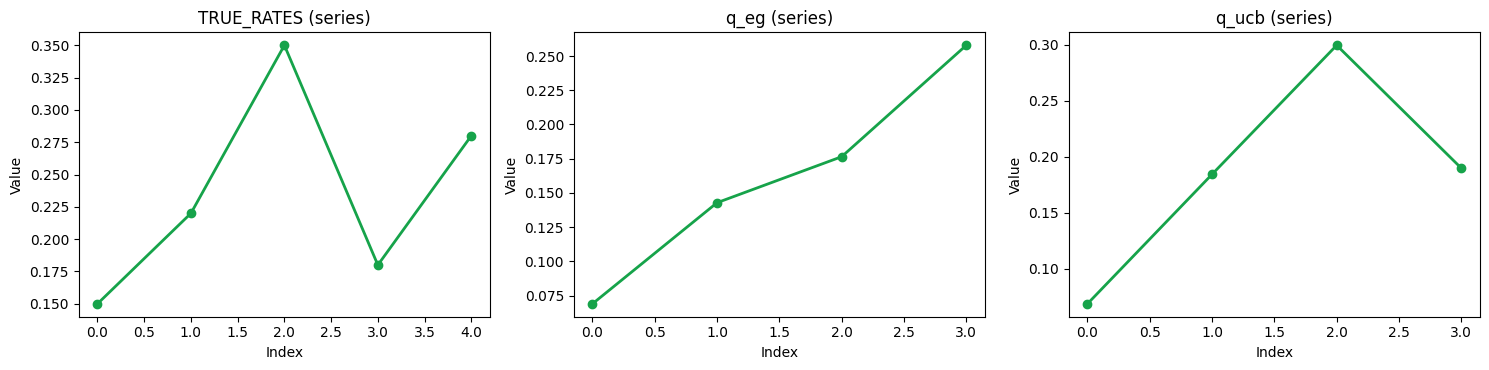

In [8]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** This exercise checks whether students can reason about exploration choices and justify them instead of memorizing method names.

**If students remember one idea:** The goal is not to list strategies, but to defend when and why a strategy fits a task.

**Quick check before moving on:**
- Can you explain why your chosen exploration method suits the scenario?
- Can you compare two methods in terms of risk, uncertainty, and data efficiency?

**Bridge to the next step:** After this exercise, students are ready to examine real applications and advanced RL structures in Unit 5.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=10 | term=True | trunc=False


objc[77964]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x10fd50138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11024c9c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[77964]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x10fd50188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11024ca18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[77964]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x10fd4fc88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11024ca68). T

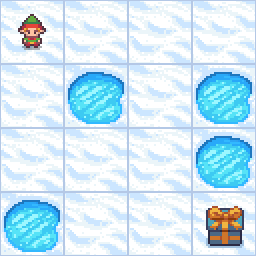

In [9]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
import course09_step_viz as cs9viz


def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
